<a href="https://colab.research.google.com/github/1021114Carlos/MIT_MM_Finance/blob/Finance-shop/Courses/Derivative_Markets/M5_Black_Schole_Merton_and_Greeks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Sets

In [1]:
from IPython.display import display, Math
import sympy as sp
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Calculate value of European put option today

In [ ]:
def euro_put_binomial_crr(s0, k, r, q, t, sigma, n):
  """
  European put price under crr binomial model
  """

  dt = t/n
  u = math.exp(sigma*math.sqrt(dt))
  d = 1.0/u
  R = math.exp((r - q)*dt)
  p = (R - d)/(u - d)
  disc = math.exp(-r*dt)

  # terminal stock price
  stock_prices = [s0*(u**j)*(d**(n - j)) for j in range(n + 1)]
  # put payoff
  values = [max(k - s, 0.0) for s in stock_prices]

  # backward induction
  for step in range(n, 0, -1):
    values = [disc*(p*values[j + 1] + (1.0 - p)*values[j])for j in range(step)]
  return values[0]



σ as a function of volatility

In [ ]:
# Put price vs volatility

def price_vs_volatility(s0, k, r, q, t, n, sigmas):
  rows = []
  for sigma in sigmas:
    price = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)
    rows.append({"sigma": sigma, "put_price": price})
  df = pd.DataFrame(rows)
  df["put_price"] = df["put_price"].round(6)
  return df

# usage
s0 = 375.0
k = 300.0
r = 0.01
q = 0.0
t = 0.5
n = 10
sigmas = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

df_vol = price_vs_volatility(s0, k, r, q, t, n, sigmas)
print(df_vol)



   sigma  put_price
0   0.20   1.086019
1   0.25   2.356337
2   0.30   5.319023
3   0.35   8.300596
4   0.40  11.291301
5   0.45  14.285612
6   0.50  17.311141


Price as a function of number of steps n and strike K

In [ ]:
# put price relative to steps n and given strike k

def price_vs_steps(s0, k, r, q, t, sigma, n_list):
  rows = []
  for n in n_list:
    price = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)
    rows.append({"n": n, "k": k, "put_price": price})
  df = pd.DataFrame(rows)
  df["put_price"] = df["put_price"].round(6)
  return df

# example to use

sigma = 0.25
n_list = list(range(10, 101, 10))

df300 = price_vs_steps(s0=375.0, k = 300.0, r=0.01, q=0.0, t=0.5, sigma=sigma, n_list=n_list)
df360 = price_vs_steps(s0=375.0, k = 360.0, r=0.01, q=0.0, t=0.5, sigma=sigma, n_list=n_list)

# print(f"k = 300 {df300} \n")
# print(f"k = 360 {df360}")

print(df300)
print("\n")
print(df360)



     n      k  put_price
0   10  300.0   2.356337
1   20  300.0   2.714365
2   30  300.0   2.777989
3   40  300.0   2.647561
4   50  300.0   2.763315
5   60  300.0   2.711934
6   70  300.0   2.740899
7   80  300.0   2.751653
8   90  300.0   2.699818
9  100  300.0   2.743575


     n      k  put_price
0   10  360.0  18.793586
1   20  360.0  18.590931
2   30  360.0  18.461655
3   40  360.0  18.373167
4   50  360.0  18.307922
5   60  360.0  18.257249
6   70  360.0  18.216401
7   80  360.0  18.223241
8   90  360.0  18.259663
9  100  360.0  18.283968


Greeks with 5% increase (numerical derivatives)

In [ ]:
# Greeks with 5% increase

"""
returns a dict: delta, gamma, theta, rho, vega
theta is given in the usual option convention (negative of dp/dt)
"""
def greeks_5pct_bump(s0, k, r, q, t, sigma, n, bump=0.05):

  p0 = euro_put_binomial_crr(s0, k, r, q, t, sigma, n)

  # Delta and Gamma
  s_up = s0*(1 + bump)
  s_down = s0*(1 - bump)
  h_s = s0*bump

  p_up = euro_put_binomial_crr(s_up, k, r, q, t, sigma, n)
  p_down = euro_put_binomial_crr(s_down, k, r, q, t, sigma, n)

  # forward delta
  delta = (p_up - p0)/(s_up - s0)

  #symmetric gamma using two-sided deltas around s0
  delta_plus = (p_up - p0)/(h_s)
  delta_minus = (p0 - p_down)/h_s
  gamma = (delta_plus - delta_minus)/(s_up - s_down)

  # theta
  t_up = t*(1 + bump)
  p_t_up = euro_put_binomial_crr(s0, k, r, q, t_up, sigma, n)
  dp_dt = (p_t_up - p0)/(t_up - t)
  theta = -dp_dt  # as per convention


  # rho
  r_up = r*(1 + bump)
  p_r_up = euro_put_binomial_crr(s0, k, r_up, q, t, sigma, n)
  rho = (p_r_up - p0)/(r_up -r)

  # Vega

  sigma_up = sigma*(1 + bump)
  p_sigma_up = euro_put_binomial_crr(s0, k, r, q, t, sigma_up, n)
  vega = (p_sigma_up - p0)/(sigma_up -sigma)

  return {"Price": p0, "Delta": delta, "Gamma": gamma, "Theta": theta, "Rho": rho, "Vega": vega}

# Example use

greeks = greeks_5pct_bump(s0=375.0, k=300.0, r=0.01, q=0.0, t=0.5, sigma=0.25, n=10)
for name, value in greeks.items():
  print(f"{name:6s}: {value:.6f}")



Price : 2.356337
Delta : -0.043801
Gamma : 0.002653
Theta : -14.244658
Rho   : -14.952611
Vega  : 59.047721


2a)

In [ ]:
nodes = [{"name": "s0", "x": 0, "y": 105.000}, {"name": "su", "x": 1, "y": 115.581}, {"name": "sd", "x": 1, "y": 93.489},
         {"name": "suu", "x": 2, "y": 127.229}, {"name": "sud", "x": 2, "y": 102.910}, {"name": "sdd", "x": 2, "y": 83.240}]

edges_idx = [(0,1), (0, 2), (1, 3), (1, 4), (2, 4), (2, 5)]

edge_x = []
edge_y = []

for i, j in edges_idx:
  edge_x += [nodes[i]["x"], nodes[j]["x"], None]
  edge_y += [nodes[i]["y"], nodes[j]["y"], None]

edges_trace = go.Scatter(x=edge_x, y=edge_y, mode="lines", line=dict(width=1), hoverinfo="none", showlegend=False)

node_x = [n["x"] for n in nodes]
node_y = [n["y"] for n in nodes]

nodes_trace = go.Scatter(x=node_x, y=node_y, mode="markers+text", text = [f"{y:.3f}" for y in node_y], textposition='top center',
                         hovertext=[f"{n['name']}<br>t={n['x']}, s={n['y']:.3f}" for n in nodes], hoverinfo="text", marker=dict(size=10),
                         showlegend=False)


fig = go.Figure(data=[edges_trace, nodes_trace])

fig.update_layout(title="Binomial Stock Price Tree (h = 0.5 years)",
                  xaxis_title = "Time Step",
                  yaxis_title="Stock Price",
                  xaxis=dict(dtick=1, range=[-0.2, 2.2]),
                  template="simple_white")
fig.show()



In [ ]:
print("Risk neutral probability \n")
display(Math(r"q* = \frac{{(1 + r)-d}}{{u - d}}"))
print("\n")
print("Risk neutral probability with continuous compounding.\n")
display(Math(r"q^* = \frac{e^{rt}-d}{u - d}"))

Risk neutral probability 



<IPython.core.display.Math object>



Risk neutral probability with continuous compounding.



<IPython.core.display.Math object>

In [ ]:
# Find u and d
display(Math(r"u = \frac{{s_{u_1}}}{{s_0}}"))
print("\n")
display(Math(r"d = \frac{{s_{d_1}}}{{s_0}}"))


up = 115.581/105
down = 93.489/105
print("\n")
print(f"up = {up:.6f}, down = {down:.6f}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>



up = 1.100771, down = 0.890371


b)

In [ ]:
# Find volatility
display(Math(r"up = e^{(\sigma\sqrt{t})}"))

vol = math.log(up)/math.sqrt(0.5)

display(Math(rf"\sigma ={vol:.6f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

c):

In [ ]:
display(Math(r"q^* = \frac{e^{(r - \lambda)*t}-d}{u - d}"))

risk_neutra_prob = 0.4037
div_yield = r - (math.log(risk_neutra_prob*(up - down) + down)/t)
div_yield


<IPython.core.display.Math object>

0.060000007088832207

D)

In [ ]:
#Parameters
h = 0.5
r = 0.03
disc = math.exp(-r*h)
q = 0.4037
k = 100

# stock prices
s0 = 105
su = 115.581
sd = 93.489
suu = 127.229
sud = 102.910
sdd = 83.240

# payoffs at maturity (t = 1)
cuu = max(suu - k, 0.0)
cud = max(sud - k, 0.0)
cdd = max(sdd - k, 0.0)

# european call at t = 0.5
cu_E = disc*(q*cuu + (1 - q)*cud)
cd_E = disc*(q*cud + (1 - q)*cdd)

# European call at t = 0
c0_E = disc*(q*cu_E + (1 - q)*cd_E)

# at maturity, american = european
cuu_A = cuu
cud_A = cud
cdd_A = cdd

# t = 0.5
intro_u = max(su - k, 0.0)
intro_d = max(sd - k, 0.0)
cu_A = max(intro_u, cu_E)
cd_A = max(intro_d, cd_E)

# t = 0
intro_0 = max(s0 - k, 0)
c0_A_cont = disc*(q*cu_A + (1 - q)*cd_A)
c0_A = max(intro_0, c0_A_cont)

results = { "Cuu_E": cuu, "cuu_A": cuu_A, "cud_E": cud, "cud_A": cud_A,
           "cdd_E": cdd, "cdd_A": cdd_A, "cu_E": cu_E, "cu_A": cu_A,
            "cd_E": cd_E, "cd_A": cd_A, "c0_E": c0_E, "c0_A": c0_A}

for k, v in results.items():
  print(f"{k}: {v:.6f}")

Cuu_E: 27.229000
cuu_A: 27.229000
cud_E: 2.910000
cud_A: 2.910000
cdd_E: 0.000000
cdd_A: 0.000000
cu_E: 12.538091
cu_A: 15.581000
cd_E: 1.157277
cd_A: 1.157277
c0_E: 5.666080
c0_A: 6.876213


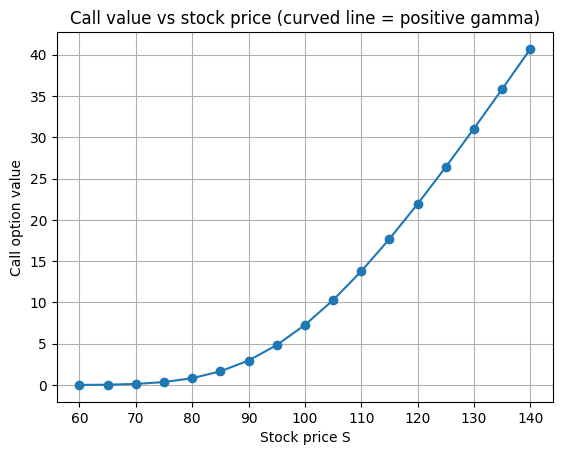

,S,CallPrice,Delta,Gamma
0,60.0,0.0084,0.0028,0.0008
1,65.0,0.0376,0.0102,0.0024
2,70.0,0.1285,0.0288,0.0053
3,75.0,0.3547,0.0656,0.0096
4,80.0,0.8227,0.1261,0.0146
5,85.0,1.6557,0.2112,0.0192
6,90.0,2.9665,0.3159,0.0223
7,95.0,4.8318,0.4311,0.0234
8,100.0,7.2778,0.5464,0.0224
9,105.0,10.2810,0.6526,0.0199


In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Black–Scholes European call price
def bs_call(S, K, r, q, sigma, T):
    if T == 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    Nd1 = 0.5 * (1 + math.erf(d1 / math.sqrt(2)))
    Nd2 = 0.5 * (1 + math.erf(d2 / math.sqrt(2)))
    return S * math.exp(-q * T) * Nd1 - K * math.exp(-r * T) * Nd2

# Parameters
K = 100
r = 0.01
q = 0.0
sigma = 0.25
T = 0.5

# Range of stock prices around 100
S_values = np.linspace(60, 140, 17)  # step 5
call_prices = [bs_call(S, K, r, q, sigma, T) for S in S_values]

# Approximate delta and gamma numerically
dS = 1.0
deltas, gammas = [], []

for S in S_values:
    C_plus = bs_call(S + dS, K, r, q, sigma, T)
    C_minus = bs_call(S - dS, K, r, q, sigma, T)
    C0 = bs_call(S, K, r, q, sigma, T)
    delta = (C_plus - C_minus) / (2 * dS)
    gamma = (C_plus - 2 * C0 + C_minus) / (dS**2)
    deltas.append(delta)
    gammas.append(gamma)

df = pd.DataFrame({"S": S_values, "CallPrice": call_prices, "Delta": deltas, "Gamma": gammas})

df_rounded = df.round(4)

plt.figure()
plt.plot(S_values, call_prices, marker="o")
plt.xlabel("Stock price S")
plt.ylabel("Call option value")
plt.title("Call value vs stock price (curved line = positive gamma)")
plt.grid(True)
plt.show()

df_rounded


5 a)

In [ ]:
# Find theoretical value of one-year european put option

s = 80
k = 83
t = 1
rfr = 3/100
q = 0   # Div yield for non-dividend paying stock
sigma = 20/100

In [ ]:
d1 = display(Math(r"\frac{\log{(\frac{s}{k})} + (r + \frac{1}{2})(T - t)}{\sigma\sqrt(T - t)}"))
print("\n")
d2 = display(Math(r"d1 - \sigma\sqrt(T - t)"))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
d1 = (math.log(s/k) + (rfr + (1/2)*sigma**2)*t)/(sigma*math.sqrt(t))
d2 = d1 - sigma*math.sqrt(t)
print(f"d1 = {d1:.6f} and d2 = {d2:.6f}")

d1 = 0.065930 and d2 = -0.134070


In [ ]:
display(Math(r"p_o = Ke^{-rT}N(-d_2) - S_0N(-d_1)"))
print("\nTo obtain N(*) we need to use integral formula (error function approxiamation)\n")
display(Math(r"N(-d_1) = 1 - N(d_1) \ and \ N(-d_2) = 1 - N(d_2)"))

<IPython.core.display.Math object>


To obtain N(*) we need to use integral formula (error function approxiamation)



<IPython.core.display.Math object>

In [ ]:
n_d1 = 0.473717
n_d2 = 0.553326

In [ ]:
p0 = k*(math.e**(-rfr*t))*(n_d2) - s*(n_d1)
p0

6.671377859589732

In [7]:
# BSM helper: standard normal CDF
def N(x: float):
  """Standard normal cumulative distribution function."""
  return 0.5*(1.0 + math.erf(x/math.sqrt(2.0)))

# BSM for European put
def bsm_put_and_delta(s0, k, rfr, sigma, t, q=0.0):
  """ s0: current stock price
      k: strike price
      rfr: risk-free-rate (continous)
      sigma: volatility
      t: time to maturity (years)
      q: divided yield (continous), default = for non-dividend paying stock.
  """

  if t <= 0:
    put_price = max(k - s0, 0.0) # at t= 0, option value is just payoff
    delta = -1.0 if s0 < k else 0.0    # Delta -1 if ITM, 0 OTM
    return put_price, delta

  d1 = (math.log(s0/k) + (rfr - q + 0.5*sigma**2)*t)/(sigma*math.sqrt(t))
  d2 = d1 - sigma*math.sqrt(t)

  # european put price
  put_price = k*math.exp(-rfr*t)*N(-d2) - s0*math.exp(-q*t)*N(-d1)

  # Deltal of a put
  delta = -math.exp(-q*t)*N(-d1)

  return put_price, delta

print("Black Scholes Merton European put pricer\n")

try:
  s0 = float(input("Current stock price s0 (e.g., 80): "))
  k = float(input("Strike price k (e.g., 83):  "))
  rfr = float(input("Risk-free rate rfr (continous, e.g., 0.03 for 3%): "))
  sigma = float(input("Volatility sigma (e.g., 0.20 for 20%): "))
  t = float(input("Time to maturity t in years (e.g., 1): "))

except ValueError:
  print("Please enter numeric values.")
  raise SystemExit

# Non dividend paying stock => q = 0
put_price, put_delta = bsm_put_and_delta(s0, k, rfr, sigma, t, q=0.0)
print("\nResults:")
print(f"Theoretical european put value: {put_price:6f} \nPut delta: {put_delta:.6f}")


SyntaxError: invalid syntax (ipython-input-3540039029.py, line 7)

b)

In [ ]:
# Write put options on 500 shares of the stock.
# if i want to delta hedge the position, how many shares of the stock do i initially short? what is the value of the bonds i buy?

